# Electron orbitals — shapes, fill order, metals

**Chemistry HL - Structure 1.3.4 and 1.3.5** (sublevels and orbital shapes;
Aufbau, Hund and Pauli for atoms and ions up to Z = 36)

A longer walkthrough in five parts:
1. What **s** and the three **p** orbitals look like
2. Two electrons per orbital (Pauli), one per orbital first (Hund)
3. Periodic-table blocks and the **diagonal Aufbau** fill order
4. Transition metals — and the **Cr / Cu** exceptions
5. Ions — **4s is lost before 3d**

The website page is the interactive version of the same material.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from matplotlib.patches import Circle, FancyArrowPatch

ACCENT = "#b4341f"
INK = "#1a1a1a"
SOFT = "#6b6b6b"
P_POS = "#2f6f8f"

# Madelung (n + l) order: lower n + l first, and for a tie, lower n first.
# That single rule is the diagonal chart, and it is why 4s (4 + 0) comes
# before 3d (3 + 2). It runs all the way to 7p so the chart below is complete.
AUFBAU = [
    (1, "s", 2),
    (2, "s", 2), (2, "p", 6),
    (3, "s", 2), (3, "p", 6),
    (4, "s", 2), (3, "d", 10), (4, "p", 6),
    (5, "s", 2), (4, "d", 10), (5, "p", 6),
    (6, "s", 2), (4, "f", 14), (5, "d", 10), (6, "p", 6),
    (7, "s", 2), (5, "f", 14), (6, "d", 10), (7, "p", 6),
]

# The only two exceptions IB asks for (atoms up to Z = 36). Heavier atoms
# have more (Mo, Ag, Au, ...), which this deliberately does not model.
EXCEPTIONS = {
    24: {"4s": 1, "3d": 5},   # Cr
    29: {"4s": 1, "3d": 10},  # Cu
}

In [2]:
def fill_aufbau(z, apply_exception=True):
    remaining, config = z, {}
    for n, letter, cap in AUFBAU:
        if remaining <= 0:
            break
        key = f"{n}{letter}"
        take = min(cap, remaining)
        config[key] = take
        remaining -= take
    if apply_exception and z in EXCEPTIONS:
        config.update(EXCEPTIONS[z])
    return config


def ion_config(z, charge):
    """Ground-state configuration of the ion of element z with this charge.

    Electrons come OFF in a different order from the one they go on in: a
    positive ion loses electrons from the highest shell n first (and within
    it, p before s). So Fe loses its two 4s electrons before touching 3d:
    Fe2+ is [Ar] 3d6, not [Ar] 4s2 3d4. Once 3d holds electrons it is lower
    in energy than 4s, and the 4s electrons are the outermost.
    """
    if charge <= 0:
        # negative ions: the extra electrons simply go in by Aufbau
        return fill_aufbau(z - charge, apply_exception=False)
    config = fill_aufbau(z)
    for _ in range(charge):
        outer = max(config, key=lambda k: (int(k[0]), "spdf".index(k[1])))
        config[outer] -= 1
        if config[outer] == 0:
            del config[outer]
    return config


def config_string(config):
    order = [f"{n}{L}" for n, L, _ in AUFBAU]
    cores = [(2, "[He]"), (10, "[Ne]"), (18, "[Ar]"), (36, "[Kr]")]
    z = sum(config.values())
    core_z, core_label = 0, ""
    for cz, label in cores:
        if z > cz:
            core_z, core_label = cz, label
    if not core_label:
        return " ".join(f"{k}{config[k]}" for k in order if config.get(k))
    core_cfg = fill_aufbau(core_z, apply_exception=False)
    valence = [
        f"{k}{config[k]}"
        for k in order
        if k in config and config[k] != core_cfg.get(k, 0)
    ]
    return f"{core_label} " + " ".join(valence)


def valence_keys(config):
    z = sum(config.values())
    cores = [2, 10, 18, 36]
    core_z = max((c for c in cores if z > c), default=0)
    core_cfg = fill_aufbau(core_z, apply_exception=False) if core_z else {}
    order = [f"{n}{L}" for n, L, _ in AUFBAU]
    return [k for k in order if k in config and config[k] != core_cfg.get(k, 0)]


def occupancy(n_orb, electrons):
    """Electrons per orbital in one sublevel, filled by Hund's rule:
    one in every orbital (parallel spins) before any orbital gets a second."""
    occ = [0] * n_orb
    for e in range(min(electrons, n_orb)):
        occ[e] = 1
    for e in range(n_orb, electrons):
        occ[e - n_orb] = 2
    return occ

The drawing helpers - the same ones the script uses.

In [3]:
# --- drawing helpers -------------------------------------------------------
def _lobe_path(cx, cy, axis, sign, scale):
    """Elongated teardrop lobe: r = R·cos³(φ), pointed at the nucleus."""
    phis = np.linspace(-np.pi / 2, np.pi / 2, 120)
    base = axis + (np.pi if sign < 0 else 0)
    xs, ys = [cx], [cy]
    for phi in phis:
        c = np.cos(phi)
        if c <= 0:
            continue
        r = scale * c**3 * (0.35 + 0.65 * c)
        ang = base + phi
        xs.append(cx + r * np.cos(ang))
        ys.append(cy + r * np.sin(ang))
    xs.append(cx)
    ys.append(cy)
    return np.array(xs), np.array(ys)


# x to the right, y up, and z drawn down-left: z points out of the page,
# towards you. That keeps the axes right-handed (x × y = z); drawing z up and
# to the right would quietly make them left-handed.
_INV = 1 / np.sqrt(2)
AXIS_DIRS = {"x": (1.0, 0.0), "y": (0.0, 1.0), "z": (-_INV, -_INV)}


def draw_axes(ax, cx, cy, scale=1.15, emphasize=None):
    """Draw x, y, z axes; z runs to the corner of the x–y square."""
    for name, (dx, dy) in AXIS_DIRS.items():
        hot = name == emphasize
        scl = np.sqrt(2) if name == "z" else 1.0
        L = scale * scl * (1.05 if hot else 0.92)
        color = INK if hot else SOFT
        lw = 1.5 if hot else 1.0
        ax.annotate(
            "",
            xy=(cx + dx * L, cy + dy * L),
            xytext=(cx - dx * L * 0.9, cy - dy * L * 0.9),
            arrowprops=dict(arrowstyle="->", color=color, lw=lw),
        )
        ax.text(
            cx + dx * (L + 0.16),
            cy + dy * (L + 0.16),
            name,
            ha={"x": "left", "y": "center", "z": "right"}[name],
            va={"x": "center", "y": "bottom", "z": "top"}[name],
            fontsize=10,
            fontweight="bold" if hot else "normal",
            color=color,
        )


def draw_s(ax, cx, cy, scale=0.9):
    draw_axes(ax, cx, cy, scale=scale + 0.25)
    ax.add_patch(Circle((cx, cy), scale, facecolor=ACCENT, edgecolor=INK,
                        alpha=0.3, lw=1.4))
    ax.plot(cx, cy, "o", color=INK, ms=4)
    ax.text(cx, cy - scale - 0.45, "s", ha="center", va="top",
            fontsize=12, fontweight="bold", color=INK)


def draw_p(ax, cx, cy, axis_name, label, scale=1.0):
    dx, dy = AXIS_DIRS[axis_name]
    axis_ang = np.arctan2(dy, dx)
    draw_axes(ax, cx, cy, scale=scale + 0.2, emphasize=axis_name)
    lobe_scale = scale * (0.9 if axis_name == "x" else 1.0)
    for sign in (1, -1):
        x, y = _lobe_path(cx, cy, axis_ang, sign, lobe_scale)
        ax.fill(x, y, color=P_POS, alpha=0.4, lw=0)
        ax.plot(x, y, color=INK, lw=1.15)
    ax.plot(cx, cy, "o", color=INK, ms=3)
    ax.text(cx, cy - scale - 0.45, label, ha="center", va="top",
            fontsize=12, fontweight="bold", color=INK)


def draw_orbital_box(ax, x, y, occ, hot=False):
    color = ACCENT if hot else INK
    ax.add_patch(mpatches.Rectangle((x, y), 0.5, 1.1, fill=False,
                                    edgecolor=color, lw=1.5))
    # side by side, so a pair reads as ↑↓ and not as one double-headed arrow
    up_x = x + (0.17 if occ == 2 else 0.25)
    if occ >= 1:
        ax.annotate("", xy=(up_x, y + 0.9), xytext=(up_x, y + 0.2),
                    arrowprops=dict(arrowstyle="->", color=INK, lw=1.3))
    if occ == 2:
        ax.annotate("", xy=(x + 0.33, y + 0.2), xytext=(x + 0.33, y + 0.9),
                    arrowprops=dict(arrowstyle="->", color=INK, lw=1.3))


def draw_config_boxes(ax, config, title, highlight=None):
    ax.axis("off")
    ax.set_xlim(0, 11)
    ax.set_ylim(0, 4.2)
    ax.set_title(title, loc="left", fontsize=11)
    present = valence_keys(config)
    x = 0.3
    for key in present:
        n_orb = {"s": 1, "p": 3, "d": 5, "f": 7}[key[1]]
        occ = occupancy(n_orb, config.get(key, 0))
        hot = bool(highlight and key in highlight)
        ax.text(x + n_orb * 0.55 / 2, 3.35, key, ha="center", fontsize=10,
                color=ACCENT if hot else INK,
                fontweight="bold" if hot else "normal")
        for i, n in enumerate(occ):
            draw_orbital_box(ax, x + i * 0.6, 2.0, n, hot=hot)
        x += n_orb * 0.6 + 0.5
    ax.text(0.3, 1.1, config_string(config), fontsize=11, color=INK,
            fontfamily="monospace")

## 1. Shapes — s, pₓ, pᵧ, p_z

s is a sphere. Each p orbital is a dumbbell along one axis (x, y or z), and
the three are mutually perpendicular. Every orbital holds at most **two
electrons of opposite spin** (↑↓). The z-axis is drawn down-left: it points
out of the page, towards you.

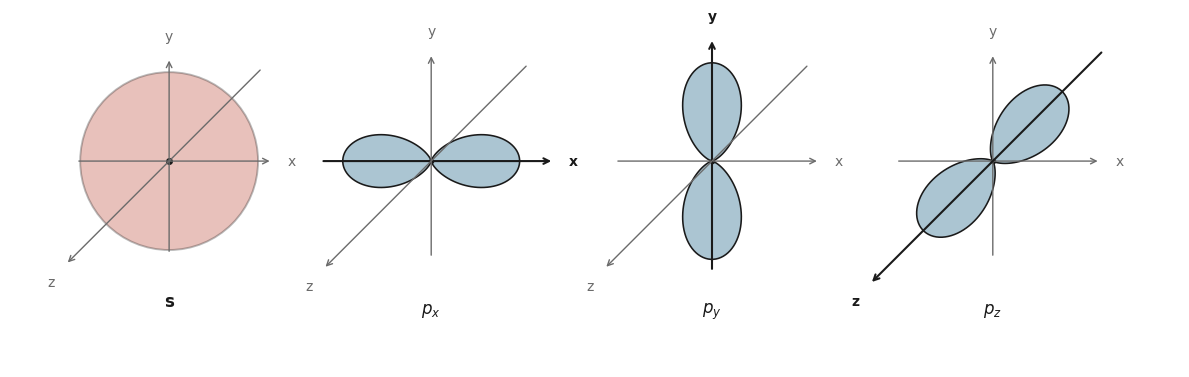

In [4]:
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.set_xlim(-0.5, 12)
ax.set_ylim(-2.0, 1.6)
ax.set_aspect("equal")
ax.axis("off")
draw_s(ax, 1.2, 0.2, scale=0.95)
draw_p(ax, 4.0, 0.2, axis_name="x", label=r"$p_x$", scale=1.05)
draw_p(ax, 7.0, 0.2, axis_name="y", label=r"$p_y$", scale=1.05)
draw_p(ax, 10.0, 0.2, axis_name="z", label=r"$p_z$", scale=1.05)
plt.tight_layout()
plt.show()

## 2. Two electrons per orbital

**Pauli:** an orbital holds at most two electrons, and they must have opposite
spins. **Hund:** orbitals of the same sublevel (the three p, the five d) fill
singly, with parallel spins, before any electrons pair up. `occupancy` does
exactly that - it is what puts one arrow in every 3d box of Cr below.

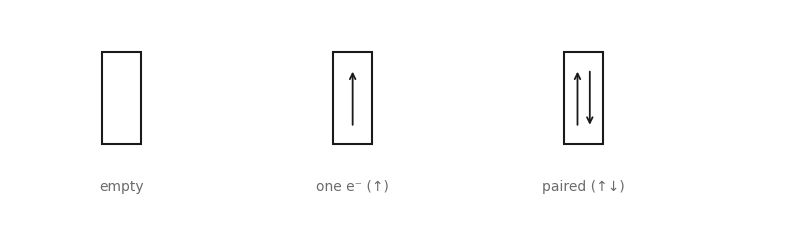

Three electrons in a p sublevel: [1, 1, 1]  (Hund: all unpaired)
Four electrons in a p sublevel:  [2, 1, 1]  (only now does one pair up)


In [5]:
fig, ax = plt.subplots(figsize=(8, 2.4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 2.5)
ax.axis("off")
for i, (occ, lab) in enumerate(zip([0, 1, 2], ["empty", "one e⁻ (↑)", "paired (↑↓)"])):
    x = 1.2 + i * 3
    draw_orbital_box(ax, x, 0.9, occ)
    ax.text(x + 0.25, 0.35, lab, ha="center", color=SOFT)
plt.tight_layout()
plt.show()

print("Three electrons in a p sublevel:", occupancy(3, 3), " (Hund: all unpaired)")
print("Four electrons in a p sublevel: ", occupancy(3, 4), " (only now does one pair up)")

## 3. Diagonal fill order

Electrons fill by the Madelung / diagonal rule: lower n + l first, and for a
tie, lower n first. So **4s (4 + 0) comes before 3d (3 + 2)**, which is why
the d-block (transition metals) starts after Ca.

In [6]:
print("Fill order:")
print(" → ".join(f"{n}{L}" for n, L, _ in AUFBAU))
print()
print("So after [Ar] comes 4s (K, Ca), then 3d (Sc → Zn).")

Fill order:
1s → 2s → 2p → 3s → 3p → 4s → 3d → 4p → 5s → 4d → 5p → 6s → 4f → 5d → 6p → 7s → 5f → 6d → 7p

So after [Ar] comes 4s (K, Ca), then 3d (Sc → Zn).


## 4. Metals and exceptions — *why* Cr and Cu

Fe follows Aufbau. Cr and Cu do not: Cr is `[Ar] 4s¹ 3d⁵` (not `4s² 3d⁴`),
and Cu is `[Ar] 4s¹ 3d¹⁰` (not `4s² 3d⁹`).

**The IB-level reason:** a half-filled (d⁵) or completely filled (d¹⁰) d
sublevel is especially stable, and in these atoms 4s and 3d are very close in
energy - so moving one electron from 4s to 3d costs little and lowers the
energy overall.

**Beyond IB, for the curious:** electrons with parallel spins in different
orbitals keep further apart and repel each other less (the *exchange energy*
that also lies behind Hund's rule). Cr's 4s¹ 3d⁵ has six parallel spins
instead of four. The reason a full d¹⁰ is favoured is subtler, and not
something IB asks you to explain.

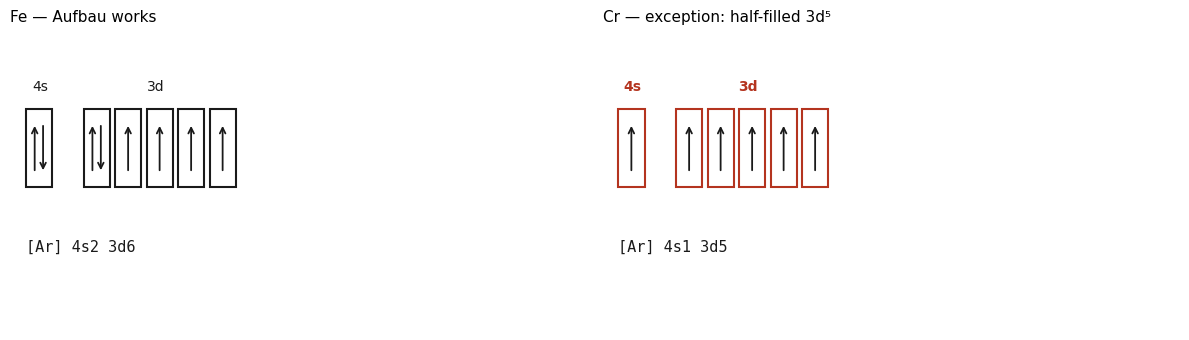

Fe: [Ar] 4s2 3d6           (Aufbau alone: [Ar] 4s2 3d6)
Cr: [Ar] 4s1 3d5           (Aufbau alone: [Ar] 4s2 3d4)  ← exception
Cu: [Ar] 4s1 3d10          (Aufbau alone: [Ar] 4s2 3d9)  ← exception
Zn: [Ar] 4s2 3d10          (Aufbau alone: [Ar] 4s2 3d10)


In [7]:
fig, (a, b) = plt.subplots(1, 2, figsize=(12, 3.5))
draw_config_boxes(a, fill_aufbau(26), "Fe — Aufbau works")
draw_config_boxes(b, fill_aufbau(24), "Cr — exception: half-filled 3d⁵", highlight={"4s", "3d"})
plt.tight_layout()
plt.show()

for z, sym in [(26, "Fe"), (24, "Cr"), (29, "Cu"), (30, "Zn")]:
    naive = config_string(fill_aufbau(z, apply_exception=False))
    actual = config_string(fill_aufbau(z))
    mark = "  ← exception" if naive != actual else ""
    print(f"{sym}: {actual:<22} (Aufbau alone: {naive}){mark}")

## 5. Ions — 4s goes first

A classic exam trap. 4s **fills** before 3d, but it is also **emptied**
before 3d: once 3d holds electrons, the 4s electrons are the outermost, and a
positive ion loses them first. So Fe²⁺ is `[Ar] 3d⁶`, not `[Ar] 4s² 3d⁴`.

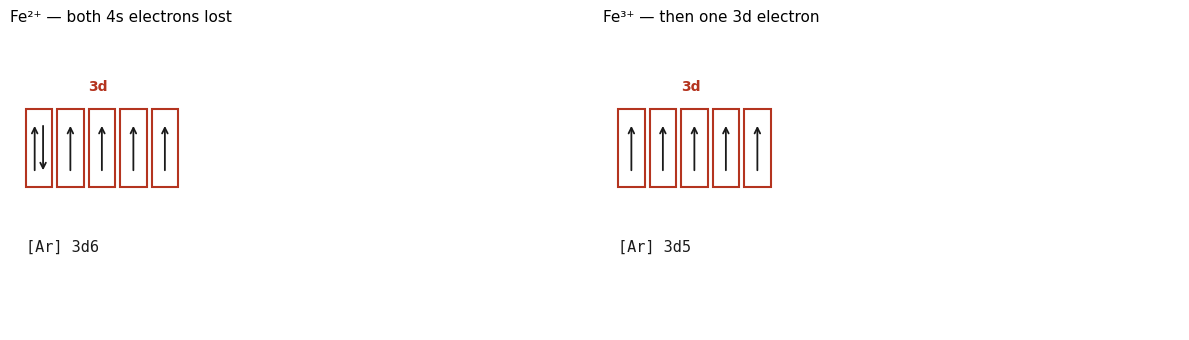

Fe2+:  [Ar] 3d6
Fe3+:  [Ar] 3d5
Cr3+:  [Ar] 3d3
Cu+:   [Ar] 3d10
Cu2+:  [Ar] 3d9
Zn2+:  [Ar] 3d10


In [8]:
fig, (a, b) = plt.subplots(1, 2, figsize=(12, 3.5))
draw_config_boxes(a, ion_config(26, 2), "Fe²⁺ — both 4s electrons lost", highlight={"3d"})
draw_config_boxes(b, ion_config(26, 3), "Fe³⁺ — then one 3d electron", highlight={"3d"})
plt.tight_layout()
plt.show()

for z, sym, charge in [(26, "Fe", 2), (26, "Fe", 3), (24, "Cr", 3),
                       (29, "Cu", 1), (29, "Cu", 2), (30, "Zn", 2)]:
    ion = f"{sym}{charge if charge > 1 else ''}+"
    print(f"{ion + ':':<6} {config_string(ion_config(z, charge))}")

## Try changing

- In part 4, swap Cr for Cu (`fill_aufbau(29)`).
- Add Mn (Z = 25) — Aufbau works: `[Ar] 4s² 3d⁵`, already half-filled.
- Try other ions with `ion_config`, e.g. `ion_config(25, 2)` for Mn²⁺
  (`[Ar] 3d⁵`) or `ion_config(17, -1)` for Cl⁻ (`[Ne] 3s² 3p⁶`).